## Model Evaluation

### Notebook Objectives
- Selection of the best-performing model
- Feature importance analysis of the selected model
- Error analysis using residuals of the best model

In [ ]:
# Projekt-Root zum Pfad hinzufügen
import sys
sys.path.append("..") # damit src/ Module gefunden werden

In [ ]:
# Imports & Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error

from src.evaluate import load_best_model, load_predictions

In [ ]:
# Bestes Modell und Vorhersagen laden

model, best_key, best_metrics = load_best_model()
print("Bestes Modell:", best_key)
print("Metriken:", best_metrics)

pred_df = load_predictions(best_key)  # enthält y_true, y_pred (im Original-Raum)
pred_df.head()


Vorhersagen geladen: rf (/Users/lukas/data-projects/data-portfolio/data-science/airbnb-price-prediction/models/predictions_rf.csv) – 2000 Zeilen
Vorhersagen geladen: rf_log (/Users/lukas/data-projects/data-portfolio/data-science/airbnb-price-prediction/models/predictions_rf_log.csv) – 2000 Zeilen
Vorhersagen geladen: xgb_log (/Users/lukas/data-projects/data-portfolio/data-science/airbnb-price-prediction/models/predictions_xgb_log.csv) – 2000 Zeilen

Bestes Modell (nach RMSE): rf_log (RMSE=64.84)
Modell geladen: rf_log (/Users/lukas/data-projects/data-portfolio/data-science/airbnb-price-prediction/models/rf_log_pipeline.pkl)
Bestes Modell: rf_log
Metriken: {'rmse': np.float64(64.8417441075473), 'mae': 43.92301052912904, 'r2': 0.3995511211402779}


,y_true,y_pred
0,77.0,112.314887
1,441.0,120.414439
2,83.0,84.674616
3,113.0,86.080948
4,111.0,92.988163


In [ ]:
# Feature Importance analysieren

best_model = model  # nur zur Klarheit

preprocess = best_model.named_steps["preprocess"]
preprocess.transformers_


[('num',
  Pipeline(steps=[('scaler', StandardScaler())]),
  ['minimum_nights',
   'number_of_reviews',
   'review_scores_rating',
   'latitude',
   'longitude',
   'amenity_count']),
 ('cat',
  Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]),
  ['neighbourhood', 'room_type'])]

In [ ]:
# Saubere Feature-Namen extrahieren

# Numerische Features 
num_features = preprocess.transformers_[0][2]

# Kategorische Features (OneHotEncoder)
cat_pipeline = preprocess.transformers_[1][1]
onehot = cat_pipeline.named_steps["onehot"]
cat_features = onehot.get_feature_names_out(
    preprocess.transformers_[1][2]
)

# Gesamte Feature-Liste
feature_names = list(num_features) + list(cat_features)

print(f"Anzahl Features nach OneHot-Encoding: {len(feature_names)}")
print(feature_names[:10])

Anzahl Features nach OneHot-Encoding: 25
['minimum_nights', 'number_of_reviews', 'review_scores_rating', 'latitude', 'longitude', 'amenity_count', 'neighbourhood_I Centro Storico', 'neighbourhood_II Parioli/Nomentano', 'neighbourhood_III Monte Sacro', 'neighbourhood_IV Tiburtina']


In [ ]:
# Feature Importances aus bestem Modell extrahieren

estimator = best_model.named_steps["model"]

if not hasattr(estimator, "feature_importances_"):
    raise AttributeError("Modell unterstützt keine feature_importances_")

importances = estimator.feature_importances_
print(f"Anzahl Feature Importances: {len(importances)}")

Anzahl Feature Importances: 25


In [ ]:
# Sanity-Check
assert len(importances) == len(feature_names), "Feature-Namen und Importances haben unterschiedliche Länge!"

In [ ]:
# Feature Importances in DataFrame zusammenfassen und sortieren

feature_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.head(20)

print(feature_importance_df.columns)


Index(['Feature', 'Importance'], dtype='object')


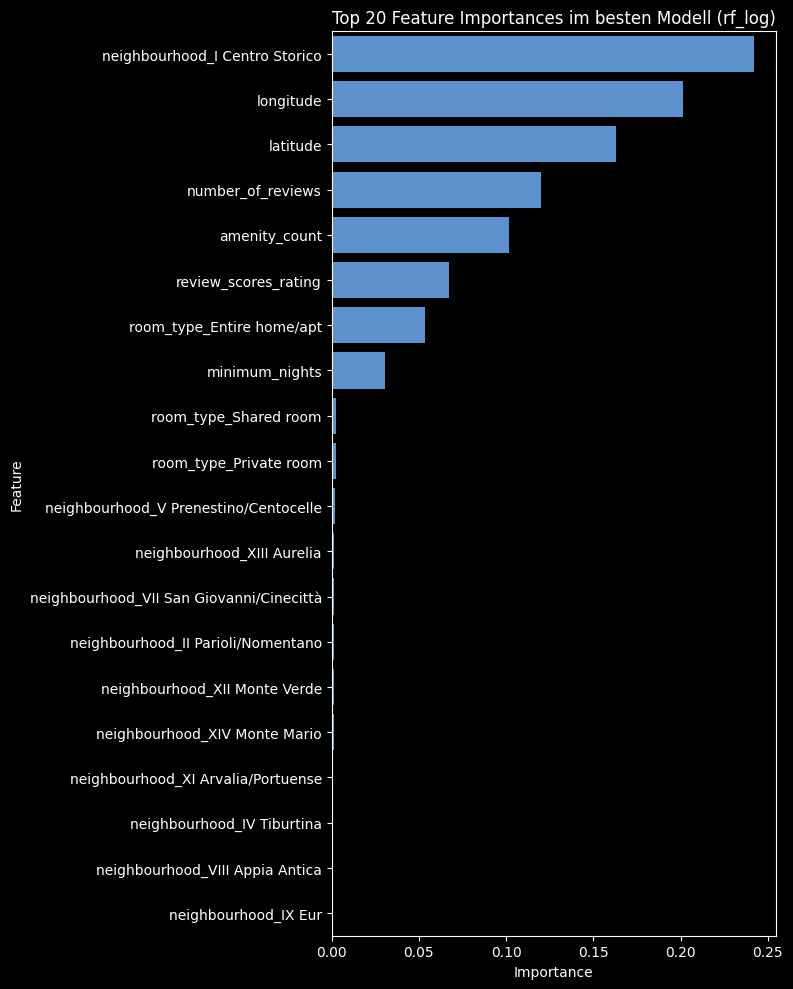

In [ ]:
# Feature Importances visualisieren (Top n)

top_n = 20
plt.figure(figsize=(8, 10))

sns.barplot(
    data=feature_importance_df.head(top_n), 
    x="Importance", 
    y="Feature", 
    color="#4A90E2"
)
plt.title(f"Top {top_n} Feature Importances im besten Modell ({best_key})")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

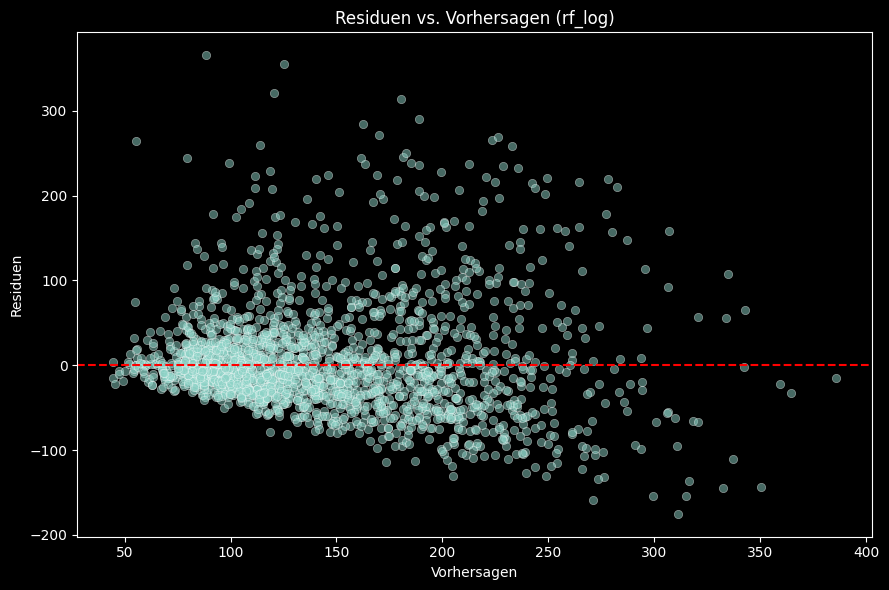

In [ ]:
# Residuen analysieren

# Residuen berechnen
best_pred_df = pred_df.copy()  # umbenennen für Klarheit
best_pred_df["residual"] = best_pred_df["y_true"] - best_pred_df["y_pred"]

# Residuen vs. Vorhersagen

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=best_pred_df, 
    x="y_pred", 
    y="residual",
    alpha=0.5
)
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residuen vs. Vorhersagen ({best_key})")
plt.xlabel("Vorhersagen")
plt.ylabel("Residuen")
plt.tight_layout()
plt.show()


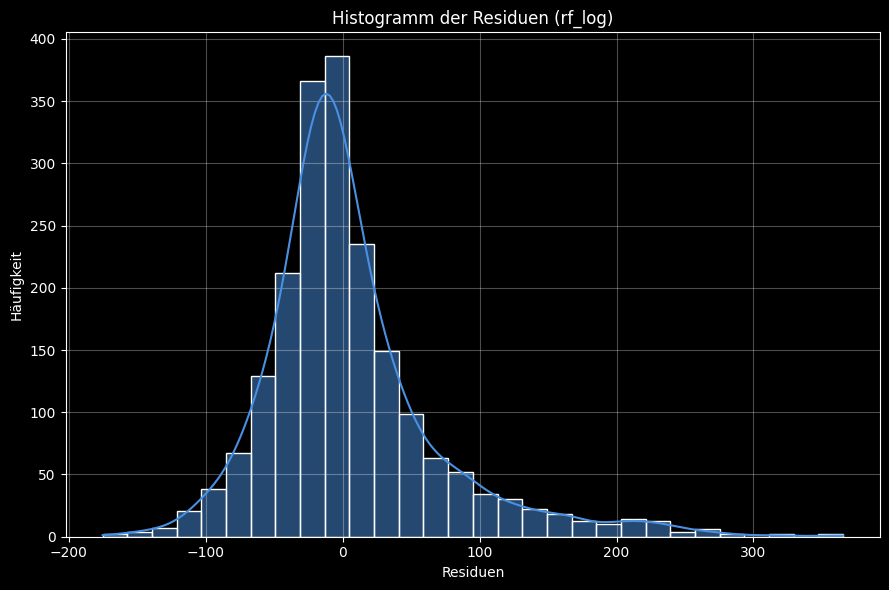

In [ ]:
# Histogramm der Residuen

plt.figure(figsize=(9, 6))
sns.histplot(best_pred_df["residual"], bins=30, kde=True, color="#4A90E2")
plt.title(f"Histogramm der Residuen ({best_key})")
plt.xlabel("Residuen")
plt.ylabel("Häufigkeit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

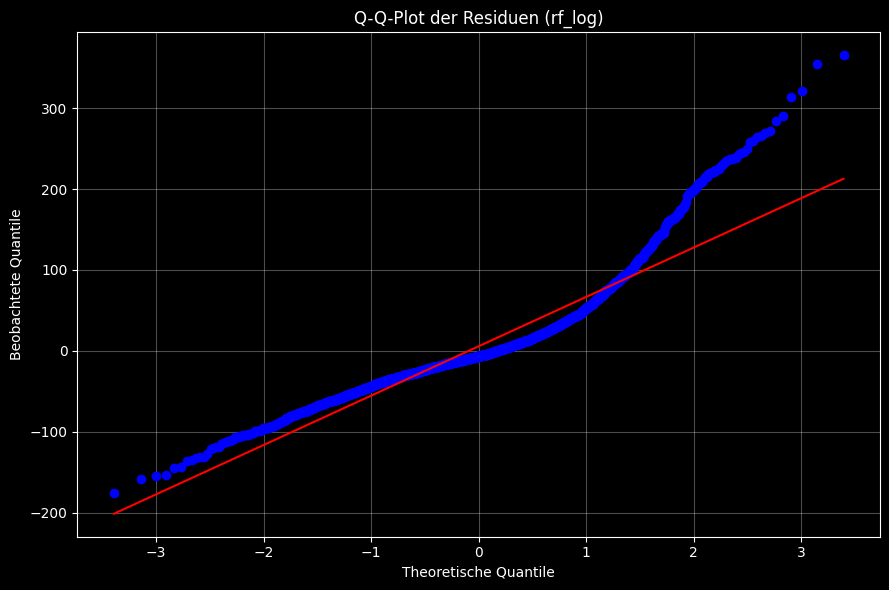

In [ ]:
# Q-Q-Plot der Residuen

plt.figure(figsize=(9, 6))
stats.probplot(best_pred_df["residual"], dist="norm", plot=plt)
plt.title(f"Q-Q-Plot der Residuen ({best_key})")
plt.xlabel("Theoretische Quantile")
plt.ylabel("Beobachtete Quantile")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# RSME nach Preis-Qantilen

best_pred_df["price_quantile"] = pd.qcut(best_pred_df["y_true"], q=5, labels= ["q1", "q2", "q3", "q4", "q5"])  
rsme_by_quantile = best_pred_df.groupby("price_quantile", observed=False).apply(
    lambda df: np.sqrt(mean_squared_error(df["y_true"], df["y_pred"])), include_groups=False
) 

rsme_by_quantile

price_quantile
q1     33.540792
q2     36.375970
q3     45.429897
q4     45.840103
q5    120.275961
dtype: float64

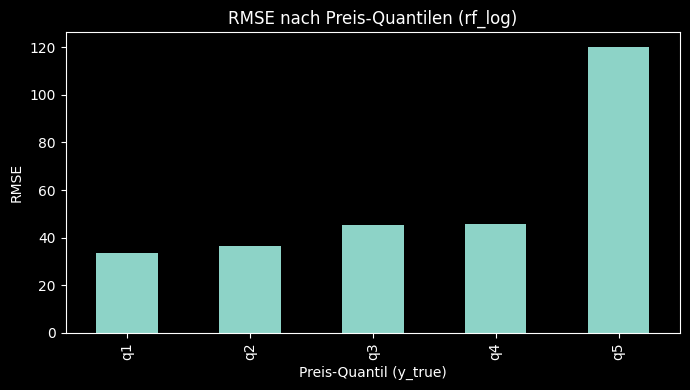

In [ ]:
# RSME nach Preis-Qantilen visualisieren

rsme_by_quantile.plot(kind="bar", figsize=(7, 4))
plt.ylabel("RMSE")
plt.xlabel("Preis-Quantil (y_true)")
plt.title(f"RMSE nach Preis-Quantilen ({best_key})")
plt.tight_layout()
plt.show()


## Conclusion

### Model Comparison
- Evaluated models show very similar performance when measured by RMSE
- Log transformation of the target variable does not lead to a meaningful improvement in model performance

### Feature Importance
- Proximity to the city center is the most important price driver
- Property characteristics are of secondary importance  
  (exception: private vs. shared accommodations)
- The number of reviews appears among the most important features,  
  while the review score itself does not
- The number of amenities is not among the most important features

### Residual Analysis
- Residuals are approximately normally distributed, with noticeable right-sided fat tails
- While the model performs well in the low to mid price range, it shows clear weaknesses for higher-priced listings

### Future Improvements
- Extract more detailed features (e.g., specific amenities), particularly to improve predictions for high-priced listings
- Apply models specialized for categorical variables (e.g., CatBoost) or for different price segments (e.g., mixture-of-experts approaches)